# Rozpoznanie choroby Alzheimera na bazie koherencji EEG

Notebook realizuje klasyfikację choroby Alzheimera na podstawie spoczynkowych
sygnałów EEG z katalogu `EEG-Alzheimer`.

- z każdego badanego wczytywany jest sygnał EEG w formacie BIDS/EEGLAB,
- sygnał dzielony jest na krótkie okna,
- dla każdego okna liczona jest koherencja między parami kanałów EEG w kilku
  pasmach częstotliwości,
- macierze koherencji są wejściem do sieci konwolucyjnej,
- warstwa falkowa jest elementem wewnątrz CNN, a nie osobnym etapem
  przygotowania obrazów CWT,
- wybrane hiperparametry modelu są przeszukiwane na walidacji grupowanej po
  pacjentach.

Klasyfikacja jest binarna: `A` oznacza grupę Alzheimer, a `C` grupę kontrolną.
Grupa `F` z frontotemporal dementia jest pomijana, ponieważ temat dotyczy
rozpoznania choroby Alzheimera względem osób zdrowych.

In [1]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt

import mne
from scipy.signal import coherence, correlate2d
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import ParameterGrid, StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
DATASET_DIR = ROOT / "EEG-Alzheimer" / "dataset"
PARTICIPANTS_PATH = DATASET_DIR / "participants.tsv"
if not PARTICIPANTS_PATH.exists():
    raise FileNotFoundError(f"Brak pliku: {PARTICIPANTS_PATH}")

participants = pd.read_csv(PARTICIPANTS_PATH, sep="\t")
participants["Group"] = participants["Group"].str.strip()
participants["MMSE"] = pd.to_numeric(participants["MMSE"], errors="coerce")
display(participants.head())
display(participants["Group"].value_counts().rename_axis("grupa").to_frame("liczba"))

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


,liczba
grupa,
A,36
C,29
F,23


## Wczytywanie EEG i przygotowanie okien

Dataset zawiera 19 kanałów EEG, próbkowanie 500 Hz i nagrania w stanie
spoczynkowym przy zamkniętych oczach. Notebook korzysta najpierw z katalogu
`derivatives`, jeśli istnieje przetworzona wersja pliku, a w przeciwnym razie
z wersji surowej w katalogu uczestnika.

Aby obliczenia były możliwe do wykonania na zwykłym laptopie, z każdego
pacjenta pobierana jest ograniczona liczba okien. Podział trening-test jest
grupowany po `participant_id`, więc okna tego samego pacjenta nie mieszają się
między zbiorami.

In [2]:
TARGET_GROUPS = {"A": 1, "C": 0}
LABEL_NAMES = {0: "kontrola", 1: "Alzheimer"}

WINDOW_SECONDS = 10
STEP_SECONDS = 20
MAX_WINDOWS_PER_SUBJECT = 8
CACHE_PATH = ROOT / "coherence_ad_vs_control_cache.npz"
EEG_BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
}


def eeglab_path_for_subject(subject_id: str) -> Path:
    derivative = DATASET_DIR / "derivatives" / subject_id / "eeg" / f"{subject_id}_task-eyesclosed_eeg.set"
    raw = DATASET_DIR / subject_id / "eeg" / f"{subject_id}_task-eyesclosed_eeg.set"
    return derivative if derivative.exists() else raw


def load_subject_eeg(subject_id: str):
    path = eeglab_path_for_subject(subject_id)
    if not path.exists():
        raise FileNotFoundError(path)
    raw = mne.io.read_raw_eeglab(path, preload=True, verbose="ERROR")
    raw.pick_types(eeg=True)
    raw.filter(1.0, 45.0, fir_design="firwin", verbose="ERROR")
    data = raw.get_data().astype(np.float32)
    channel_names = raw.ch_names
    sfreq = float(raw.info["sfreq"])
    return data, channel_names, sfreq, path


def zscore_channels(window: np.ndarray) -> np.ndarray:
    mean = window.mean(axis=1, keepdims=True)
    std = window.std(axis=1, keepdims=True) + 1e-8
    return (window - mean) / std


def iter_subject_windows(data: np.ndarray, sfreq: float):
    window_len = int(WINDOW_SECONDS * sfreq)
    step = int(STEP_SECONDS * sfreq)
    starts = np.arange(0, max(1, data.shape[1] - window_len + 1), step)
    if len(starts) > MAX_WINDOWS_PER_SUBJECT:
        idx = np.linspace(0, len(starts) - 1, MAX_WINDOWS_PER_SUBJECT).round().astype(int)
        starts = starts[idx]
    for start in starts:
        stop = start + window_len
        if stop <= data.shape[1]:
            yield start, zscore_channels(data[:, start:stop])


selected = participants[participants["Group"].isin(TARGET_GROUPS)].copy()
selected["label"] = selected["Group"].map(TARGET_GROUPS).astype(int)
display(selected.groupby("Group").agg(subjects=("participant_id", "count"), mean_age=("Age", "mean"), mean_mmse=("MMSE", "mean")).round(2))

,subjects,mean_age,mean_mmse
Group,,,
A,36,66.39,17.75
C,29,67.90,30.00


## Koherencja jako reprezentacja sygnału

Dla każdego okna liczona jest koherencja magnitude-squared coherence dla każdej
pary kanałów EEG. Wartości są następnie uśredniane w pasmach delta, theta,
alpha, beta i gamma. Wynikiem jednego okna jest tensor:

`kanał EEG x kanał EEG x pasmo`

To nie jest obraz CWT. Fale pojawią się dopiero w architekturze sieci jako
stała, różniczkowalna warstwa konwolucyjna.

In [3]:
def band_coherence_tensor(window: np.ndarray, sfreq: float, bands: dict[str, tuple[float, float]]) -> np.ndarray:
    n_channels = window.shape[0]
    band_names = list(bands)
    tensor = np.zeros((n_channels, n_channels, len(band_names)), dtype=np.float32)

    for i in range(n_channels):
        tensor[i, i, :] = 1.0
        for j in range(i + 1, n_channels):
            freqs, coh = coherence(
                window[i],
                window[j],
                fs=sfreq,
                nperseg=min(int(2 * sfreq), window.shape[1]),
                noverlap=min(int(sfreq), max(0, window.shape[1] // 2 - 1)),
            )
            for band_idx, band_name in enumerate(band_names):
                low, high = bands[band_name]
                mask = (freqs >= low) & (freqs < high)
                value = float(np.nanmean(coh[mask])) if mask.any() else 0.0
                tensor[i, j, band_idx] = value
                tensor[j, i, band_idx] = value
    return np.nan_to_num(tensor, nan=0.0, posinf=1.0, neginf=0.0)


def build_coherence_dataset():
    rows = []
    tensors = []
    first_channels = None
    for row in selected.sort_values("participant_id").itertuples(index=False):
        data, channel_names, sfreq, source_path = load_subject_eeg(row.participant_id)
        if first_channels is None:
            first_channels = channel_names
        elif channel_names != first_channels:
            raise ValueError(f"Niezgodny układ kanałów dla {row.participant_id}")

        for window_idx, (start, window) in enumerate(iter_subject_windows(data, sfreq), start=1):
            tensors.append(band_coherence_tensor(window, sfreq, EEG_BANDS))
            rows.append(
                {
                    "participant_id": row.participant_id,
                    "group": row.Group,
                    "label": int(row.label),
                    "window": window_idx,
                    "start_s": start / sfreq,
                    "source": "derivatives" if "derivatives" in str(source_path) else "raw",
                }
            )
        print(f"{row.participant_id}: {len([r for r in rows if r['participant_id'] == row.participant_id])} okien")
    return np.stack(tensors).astype(np.float32), pd.DataFrame(rows), first_channels


if CACHE_PATH.exists():
    cache = np.load(CACHE_PATH, allow_pickle=True)
    X = cache["X"].astype(np.float32)
    meta = pd.DataFrame(cache["meta"].item())
    channel_names = list(cache["channel_names"])
    print(f"Wczytano cache: {CACHE_PATH}")
else:
    X, meta, channel_names = build_coherence_dataset()
    np.savez_compressed(
        CACHE_PATH,
        X=X,
        meta=meta.to_dict(orient="list"),
        channel_names=np.array(channel_names, dtype=object),
    )
    print(f"Zapisano cache: {CACHE_PATH}")

y = meta["label"].to_numpy(dtype=np.int64)
groups = meta["participant_id"].to_numpy()

print("X:", X.shape, "| y:", y.shape, "| liczba pacjentów:", meta["participant_id"].nunique())
display(pd.crosstab(meta["participant_id"], meta["label"]).rename(columns=LABEL_NAMES).head())
display(meta["label"].map(LABEL_NAMES).value_counts().reindex(["kontrola", "Alzheimer"]))

sub-001: 8 okien
sub-002: 8 okien
sub-003: 8 okien
sub-004: 8 okien
sub-005: 8 okien
sub-006: 8 okien
sub-007: 8 okien
sub-008: 8 okien
sub-009: 8 okien
sub-010: 8 okien
sub-011: 8 okien
sub-012: 8 okien
sub-013: 8 okien
sub-014: 8 okien
sub-015: 8 okien
sub-016: 8 okien
sub-017: 8 okien
sub-018: 8 okien
sub-019: 8 okien
sub-020: 8 okien
sub-021: 8 okien
sub-022: 8 okien
sub-023: 8 okien
sub-024: 8 okien
sub-025: 8 okien
sub-026: 8 okien
sub-027: 8 okien
sub-028: 8 okien
sub-029: 8 okien
sub-030: 8 okien
sub-031: 8 okien
sub-032: 8 okien
sub-033: 8 okien
sub-034: 8 okien
sub-035: 8 okien
sub-036: 8 okien
sub-037: 8 okien
sub-038: 8 okien
sub-039: 8 okien
sub-040: 8 okien
sub-041: 8 okien
sub-042: 8 okien
sub-043: 8 okien
sub-044: 8 okien
sub-045: 8 okien
sub-046: 8 okien
sub-047: 8 okien
sub-048: 8 okien
sub-049: 8 okien
sub-050: 8 okien
sub-051: 8 okien
sub-052: 8 okien
sub-053: 8 okien
sub-054: 8 okien
sub-055: 8 okien
sub-056: 8 okien
sub-057: 8 okien
sub-058: 8 okien
sub-059: 8 oki

label,kontrola,Alzheimer
participant_id,,
sub-001,0,8
sub-002,0,8
sub-003,0,8
sub-004,0,8
sub-005,0,8


label
kontrola     232
Alzheimer    288
Name: count, dtype: int64

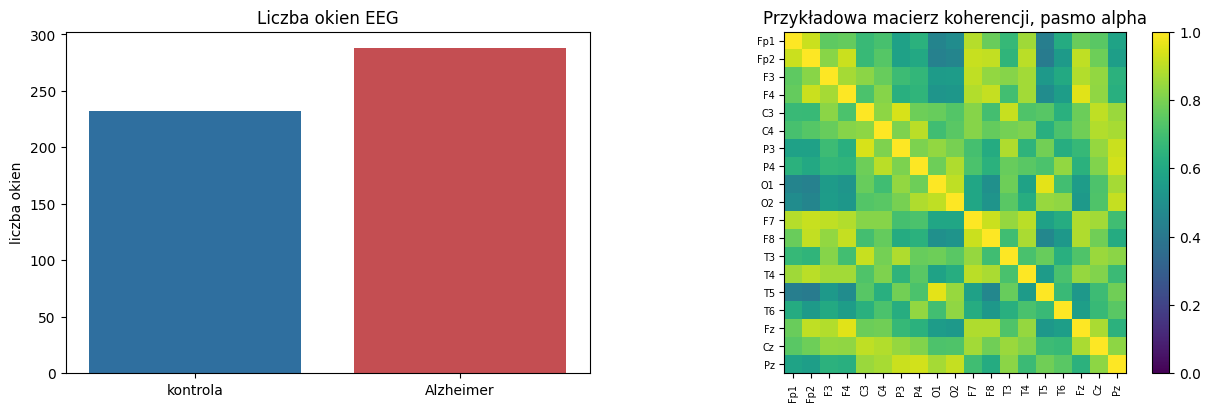

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

label_counts = meta["label"].map(LABEL_NAMES).value_counts().reindex(["kontrola", "Alzheimer"])
axes[0].bar(label_counts.index, label_counts.values, color=["#2f6f9f", "#c44e52"])
axes[0].set_title("Liczba okien EEG")
axes[0].set_ylabel("liczba okien")

example_idx = int(np.where(y == 1)[0][0])
alpha_idx = list(EEG_BANDS).index("alpha")
im = axes[1].imshow(X[example_idx, :, :, alpha_idx], vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Przykładowa macierz koherencji, pasmo alpha")
axes[1].set_xticks(range(len(channel_names)))
axes[1].set_yticks(range(len(channel_names)))
axes[1].set_xticklabels(channel_names, rotation=90, fontsize=7)
axes[1].set_yticklabels(channel_names, fontsize=7)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.show()

## Warstwa falkowa wewnątrz CNN

Poniższy blok jest napisany w NumPy/SciPy, a klasyfikator pochodzi ze
`scikit-learn`. Tworzy on bank czterech filtrów 2D z iloczynów filtrów
dolno- i górnoprzepustowych wybranej falki: `LL`, `LH`, `HL`, `HH`. Te filtry
działają jak pierwsza, stała warstwa konwolucyjna z krokiem 2.

Za nią znajduje się losowy bank filtrów konwolucyjnych 2D i pooling
statystyczny. Taki model zachowuje sens zadania w wersji zgodnej ze
`scikit-learn`: warstwa falkowa jest częścią konwolucyjnego ekstraktora
cech, a hiperparametry ekstraktora i klasyfikatora są dobierane wspólnie.

In [5]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(x, 0.0)


def conv2d_same(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    return correlate2d(image, kernel, mode="same", boundary="symm").astype(np.float32)


def pool_stats(feature_maps: list[np.ndarray]) -> np.ndarray:
    features = []
    for fmap in feature_maps:
        fmap = np.asarray(fmap, dtype=np.float32)
        features.extend(
            [
                float(fmap.mean()),
                float(fmap.std()),
                float(fmap.max()),
                float(fmap.min()),
                float(np.percentile(fmap, 25)),
                float(np.percentile(fmap, 50)),
                float(np.percentile(fmap, 75)),
                float(np.mean(np.abs(fmap))),
            ]
        )
    return np.array(features, dtype=np.float32)


class FixedWavelet2D:
    def __init__(self, wavelet: str = "db4"):
        self.wavelet = wavelet
        wavelet_obj = pywt.Wavelet(wavelet)
        lo = np.array(wavelet_obj.dec_lo[::-1], dtype=np.float32)
        hi = np.array(wavelet_obj.dec_hi[::-1], dtype=np.float32)
        self.kernels = [
            np.outer(lo, lo).astype(np.float32),
            np.outer(lo, hi).astype(np.float32),
            np.outer(hi, lo).astype(np.float32),
            np.outer(hi, hi).astype(np.float32),
        ]

    def transform_one(self, tensor: np.ndarray) -> list[np.ndarray]:
        maps = []
        for band_idx in range(tensor.shape[-1]):
            image = tensor[:, :, band_idx]
            for kernel in self.kernels:
                maps.append(relu(conv2d_same(image, kernel))[::2, ::2])
        return maps


class RandomConv2D:
    def __init__(self, n_filters: int = 8, kernel_size: int = 3, random_state: int = 42):
        self.n_filters = n_filters
        self.kernel_size = kernel_size
        rng = np.random.default_rng(random_state)
        scale = np.sqrt(2.0 / (kernel_size * kernel_size))
        kernels = rng.normal(0, scale, size=(n_filters, kernel_size, kernel_size)).astype(np.float32)
        kernels -= kernels.mean(axis=(1, 2), keepdims=True)
        self.kernels = kernels

    def transform_one(self, maps: list[np.ndarray]) -> list[np.ndarray]:
        out = []
        for fmap in maps:
            for kernel in self.kernels:
                out.append(relu(conv2d_same(fmap, kernel)))
        return out


class WaveletCoherenceCNNFeatures:
    def __init__(
        self,
        wavelet: str = "db4",
        n_filters: int = 8,
        kernel_size: int = 3,
        random_state: int = 42,
    ):
        self.wavelet = wavelet
        self.n_filters = n_filters
        self.kernel_size = kernel_size
        self.random_state = random_state

    def transform(self, X_values: np.ndarray) -> np.ndarray:
        wavelet_layer = FixedWavelet2D(self.wavelet)
        conv_layer = RandomConv2D(
            n_filters=self.n_filters,
            kernel_size=self.kernel_size,
            random_state=self.random_state,
        )
        rows = []
        for tensor in X_values:
            maps = wavelet_layer.transform_one(tensor)
            maps = conv_layer.transform_one(maps)
            rows.append(pool_stats(maps))
        return np.vstack(rows).astype(np.float32)


preview_extractor = WaveletCoherenceCNNFeatures(wavelet="db4", n_filters=4, random_state=RANDOM_STATE)
preview_features = preview_extractor.transform(X[:3])
print("Wejście:", X[:3].shape)
print("Cechy po warstwie falkowej, konwolucyjnej i poolingu:", preview_features.shape)

Wejście: (3, 19, 19, 5)
Cechy po warstwie falkowej, konwolucyjnej i poolingu: (3, 640)


## Hiperparametryzacja i walidacja po pacjentach

Hiperparametry są dobierane w małej siatce. Każda konfiguracja jest oceniana
w walidacji grupowanej po pacjentach. Dzięki temu model nie widzi okien tego
samego badanego jednocześnie w treningu i walidacji.

Po wyborze konfiguracji z najwyższym średnim `F1 macro`, wykonywana jest
osobna walidacja krzyżowa dla najlepszych hiperparametrów. Całość używa
`scikit-learn`: transformacja konwolucyjna zwraca cechy, a klasyfikator jest
klasycznym modelem sklearn.

In [6]:
PARAM_GRID = {
    "wavelet": ["haar", "db4"],
    "n_filters": [4, 8],
    "kernel_size": [3],
    "classifier": ["logreg", "mlp"],
    "C": [0.3, 1.0],
    "hidden_layer_size": [32],
}
N_SPLITS = 3


def normalize_by_train(X_values, train_idx, test_idx):
    mean = X_values[train_idx].mean(axis=(0, 1, 2), keepdims=True)
    std = X_values[train_idx].std(axis=(0, 1, 2), keepdims=True) + 1e-8
    return (X_values[train_idx] - mean) / std, (X_values[test_idx] - mean) / std


def metric_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc_abs": abs(matthews_corrcoef(y_true, y_pred)),
    }


def make_classifier(params, seed):
    if params["classifier"] == "logreg":
        estimator = LogisticRegression(
            C=params["C"],
            max_iter=1000,
            class_weight="balanced",
            random_state=seed,
        )
    elif params["classifier"] == "mlp":
        estimator = MLPClassifier(
            hidden_layer_sizes=(params["hidden_layer_size"],),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            random_state=seed,
        )
    else:
        raise ValueError(params["classifier"])
    return make_pipeline(StandardScaler(), estimator)


def fit_one_model(params, X_train, y_train, X_val, y_val, seed):
    extractor = WaveletCoherenceCNNFeatures(
        wavelet=params["wavelet"],
        n_filters=params["n_filters"],
        kernel_size=params["kernel_size"],
        random_state=seed,
    )
    X_train_features = extractor.transform(X_train)
    X_val_features = extractor.transform(X_val)
    classifier = make_classifier(params, seed)
    classifier.fit(X_train_features, y_train)
    pred = classifier.predict(X_val_features)
    return extractor, classifier, pred


search_cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
search_rows = []
for params in ParameterGrid(PARAM_GRID):
    fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(search_cv.split(X, y, groups=groups), start=1):
        assert set(groups[train_idx]).isdisjoint(set(groups[val_idx]))
        X_train, X_val = normalize_by_train(X, train_idx, val_idx)
        _, _, pred = fit_one_model(params, X_train, y[train_idx], X_val, y[val_idx], RANDOM_STATE + fold)
        row = {"fold": fold, **params, **metric_row(y[val_idx], pred)}
        search_rows.append(row)
        fold_scores.append(row["f1_macro"])
    print(params, "średnie F1:", round(float(np.mean(fold_scores)), 4))

search_results = pd.DataFrame(search_rows)
search_summary = (
    search_results
    .groupby(list(PARAM_GRID.keys()))[["accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc_abs"]]
    .agg(["mean", "std"])
    .sort_values(("f1_macro", "mean"), ascending=False)
)
display(search_summary.round(4))

best_params = search_summary.index[0]._asdict() if hasattr(search_summary.index[0], "_asdict") else dict(zip(PARAM_GRID.keys(), search_summary.index[0]))
print("Najlepsze hiperparametry:", best_params)

{'C': 0.3, 'classifier': 'logreg', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 4, 'wavelet': 'haar'} średnie F1: 0.7254
{'C': 0.3, 'classifier': 'logreg', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 4, 'wavelet': 'db4'} średnie F1: 0.7303
{'C': 0.3, 'classifier': 'logreg', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 8, 'wavelet': 'haar'} średnie F1: 0.697
{'C': 0.3, 'classifier': 'logreg', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 8, 'wavelet': 'db4'} średnie F1: 0.7174
{'C': 0.3, 'classifier': 'mlp', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 4, 'wavelet': 'haar'} średnie F1: 0.7041
{'C': 0.3, 'classifier': 'mlp', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 4, 'wavelet': 'db4'} średnie F1: 0.7344
{'C': 0.3, 'classifier': 'mlp', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 8, 'wavelet': 'haar'} średnie F1: 0.704
{'C': 0.3, 'classifier': 'mlp', 'hidden_layer_size': 32, 'kernel_size': 3, 'n_filters': 8,

accuracy  \
                                                                   mean   
wavelet n_filters kernel_size classifier C   hidden_layer_size            
db4     8         3           mlp        0.3 32                  0.7420   
                                         1.0 32                  0.7420   
        4         3           mlp        1.0 32                  0.7367   
                                         0.3 32                  0.7367   
                              logreg     0.3 32                  0.7357   
haar    4         3           logreg     0.3 32                  0.7290   
db4     4         3           logreg     1.0 32                  0.7298   
haar    4         3           logreg     1.0 32                  0.7251   
db4     8         3           logreg     0.3 32                  0.7221   
                                         1.0 32                  0.7221   
haar    4         3           mlp        0.3 32                  0.7079   
                                         1.0 32                  0.7079   
        8         3           mlp        1.0 32                  0.7080   
                                         0.3 32                  0.7080   
                              logreg     0.3 32                  0.7020   
                                         1.0 32                  0.6981   

                                                                        \
                                                                   std   
wavelet n_filters kernel_size classifier C   hidden_layer_size           
db4     8         3           mlp        0.3 32                 0.0236   
                                         1.0 32                 0.0236   
        4         3           mlp        1.0 32                 0.0496   
                                         0.3 32                 0.0496   
                              logreg     0.3 32                 0.0533   
haar    4         3           logreg     0.3 32                 0.0378   
db4     4         3           logreg     1.0 32                 0.0550   
haar    4         3           logreg     1.0 32                 0.0291   
db4     8         3           logreg     0.3 32                 0.0568   
                                         1.0 32                 0.0551   
haar    4         3           mlp        0.3 32                 0.0606   
                                         1.0 32                 0.0606   
        8         3           mlp        1.0 32                 0.0590   
                                         0.3 32                 0.0590   
                              logreg     0.3 32                 0.0234   
                                         1.0 32                 0.0202   

                                                               precision_macro  \
                                                                          mean   
wavelet n_filters kernel_size classifier C   hidden_layer_size                   
db4     8         3           mlp        0.3 32                         0.7462   
                                         1.0 32                         0.7462   
        4         3           mlp        1.0 32                         0.7381   
                                         0.3 32                         0.7381   
                              logreg     0.3 32                         0.7353   
haar    4         3           logreg     0.3 32                         0.7359   
db4     4         3           logreg     1.0 32                         0.7298   
haar    4         3           logreg     1.0 32                         0.7318   
db4     8         3           logreg     0.3 32                         0.7243   
                                         1.0 32                         0.7240   
haar    4         3           mlp        0.3 32                         0.7101   
                                         1.0 32                         0.7101   


Najlepsze hiperparametry: {'wavelet': 'db4', 'n_filters': np.int64(8), 'kernel_size': np.int64(3), 'classifier': 'mlp', 'C': np.float64(0.3), 'hidden_layer_size': np.int64(32)}


In [7]:
final_cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + 100)
final_rows = []
confusion_sum = np.zeros((2, 2), dtype=int)

for fold, (train_idx, test_idx) in enumerate(final_cv.split(X, y, groups=groups), start=1):
    train_subjects = set(groups[train_idx])
    test_subjects = set(groups[test_idx])
    assert train_subjects.isdisjoint(test_subjects)

    X_train, X_test = normalize_by_train(X, train_idx, test_idx)
    extractor, classifier, pred = fit_one_model(best_params, X_train, y[train_idx], X_test, y[test_idx], RANDOM_STATE + 1000 + fold)
    row = {
        "fold": fold,
        "train_subjects": len(train_subjects),
        "test_subjects": len(test_subjects),
        "test_windows": len(test_idx),
        **metric_row(y[test_idx], pred),
    }
    final_rows.append(row)
    confusion_sum += confusion_matrix(y[test_idx], pred, labels=[0, 1])
    print(
        f"fold {fold}: acc={row['accuracy']:.3f}, f1={row['f1_macro']:.3f}, "
        f"|MCC|={row['mcc_abs']:.3f}, pacjenci testowi={sorted(test_subjects)}"
    )

final_results = pd.DataFrame(final_rows)
display(final_results)
display(final_results[["accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc_abs"]].agg(["mean", "std"]).round(4))

fold 1: acc=0.699, f1=0.699, |MCC|=0.408, pacjenci testowi=['sub-001', 'sub-002', 'sub-006', 'sub-007', 'sub-010', 'sub-020', 'sub-025', 'sub-026', 'sub-027', 'sub-031', 'sub-033', 'sub-035', 'sub-038', 'sub-039', 'sub-040', 'sub-047', 'sub-050', 'sub-053', 'sub-054', 'sub-055', 'sub-057', 'sub-063']
fold 2: acc=0.798, f1=0.793, |MCC|=0.587, pacjenci testowi=['sub-003', 'sub-004', 'sub-008', 'sub-012', 'sub-017', 'sub-018', 'sub-019', 'sub-023', 'sub-028', 'sub-032', 'sub-034', 'sub-036', 'sub-037', 'sub-042', 'sub-045', 'sub-048', 'sub-049', 'sub-059', 'sub-060', 'sub-062', 'sub-064']
fold 3: acc=0.778, f1=0.774, |MCC|=0.552, pacjenci testowi=['sub-005', 'sub-009', 'sub-011', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-021', 'sub-022', 'sub-024', 'sub-029', 'sub-030', 'sub-041', 'sub-043', 'sub-044', 'sub-046', 'sub-051', 'sub-052', 'sub-056', 'sub-058', 'sub-061', 'sub-065']


,fold,train_subjects,test_subjects,test_windows,accuracy,precision_macro,recall_macro,f1_macro,mcc_abs
0,1,43,22,176,0.698864,0.703769,0.704167,0.698854,0.407935
1,2,44,21,168,0.797619,0.793403,0.793403,0.793403,0.586806
2,3,43,22,176,0.778409,0.780080,0.771875,0.773846,0.551894


,accuracy,precision_macro,recall_macro,f1_macro,mcc_abs
mean,0.7583,0.7591,0.7565,0.7554,0.5155
std,0.0524,0.0484,0.0466,0.0499,0.0948


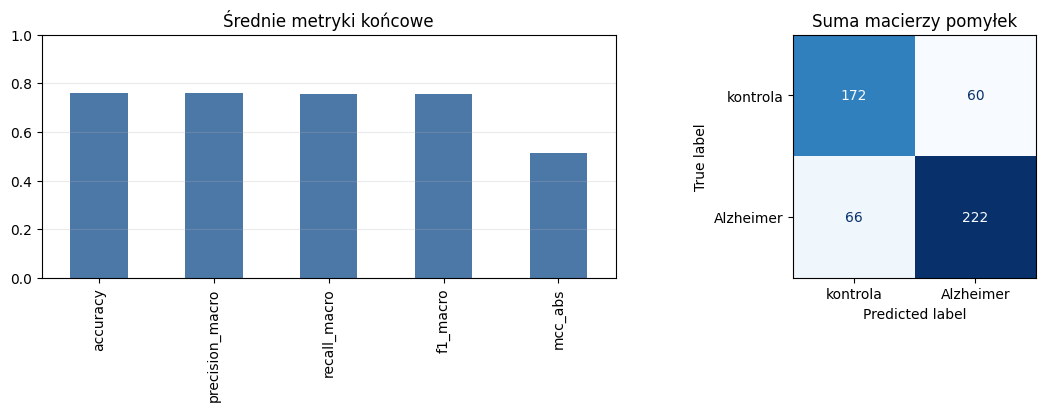

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

metric_cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "mcc_abs"]
final_results[metric_cols].mean().plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Średnie metryki końcowe")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.25)

disp = ConfusionMatrixDisplay(confusion_sum, display_labels=["kontrola", "Alzheimer"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Suma macierzy pomyłek")
plt.show()

## Wnioski

W tym rozwiązaniu koherencja EEG opisuje zależności funkcjonalne między
kanałami, a CNN analizuje wielopasmowe macierze tych zależności. Warstwa
falkowa działa wewnątrz modelu: jej filtry są stałymi filtrami falkowymi 2D,
po których następują uczone warstwy konwolucyjne.

Najważniejszy element metodologiczny to walidacja po pacjentach. Wyniki z
pojedynczych okien nie powinny być dzielone losowo bez grupowania, ponieważ
wtedy fragmenty tego samego nagrania mogłyby trafić zarówno do treningu, jak i
testu, sztucznie zawyżając jakość klasyfikacji.